In [2]:
import cv2
import os

def register_user():
    # Ask for user details
    user_name = input("Enter your name: ")
    
    # Create a folder for the user
    user_folder = f"fingerprint_dataset/{user_name}"
    os.makedirs(user_folder, exist_ok=True)
    
    # Open the camera to capture fingerprint
    cap = cv2.VideoCapture(0)
    print("Press 's' to save the fingerprint image or 'q' to quit")
    
    count = 1
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to capture image.")
            break
        
        # Show the live feed
        cv2.imshow("Fingerprint Capture", frame)
        
        # Wait for user input
        key = cv2.waitKey(1) & 0xFF
        if key == ord('s'):  # Save the image
            file_path = f"{user_folder}/fingerprint_{count}.jpg"
            cv2.imwrite(file_path, frame)
            print(f"Fingerprint image saved as {file_path}")
            count += 1
        elif key == ord('q'):  # Quit
            print("Exiting fingerprint registration.")
            break

    cap.release()
    cv2.destroyAllWindows()
    
# Register a user
register_user()


Press 's' to save the fingerprint image or 'q' to quit
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_1.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_2.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_3.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_4.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_5.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_6.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_7.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_8.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_9.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_10.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_11.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_12.jpg
Fingerprint image saved as fingerprint_dataset/ganesh/fingerprint_13.jpg
Finge

In [2]:
import os
import cv2
import numpy as np
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set image dimensions
IMG_SIZE = 224

# Function to load images and labels
def load_images_and_labels(dataset_path):
    images = []
    labels = []
    label_map = {}  # Map user folders to numeric labels
    label_index = 0

    for user_folder in os.listdir(dataset_path):
        user_path = os.path.join(dataset_path, user_folder)
        if os.path.isdir(user_path):
            # Assign numeric label
            if user_folder not in label_map:
                label_map[user_folder] = label_index
                label_index += 1

            for file in os.listdir(user_path):
                file_path = os.path.join(user_path, file)
                image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)  # Grayscale image
                image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))      # Resize to 224x224
                image = np.stack((image,)*3, axis=-1)               # Convert to 3 channels
                images.append(image)
                labels.append(label_map[user_folder])

    images = np.array(images) / 255.0  # Normalize
    labels = np.array(labels)
    return images, labels, label_map

# Load dataset
dataset_path = "fingerprint_dataset"
images, labels, label_map = load_images_and_labels(dataset_path)


Epoch 1/20
3/3 [==============================] - 13s 4s/step - loss: 1.2311 - accuracy: 0.4894 - val_loss: 0.6695 - val_accuracy: 0.5000
Epoch 2/20
3/3 [==============================] - 11s 4s/step - loss: 0.4856 - accuracy: 0.8511 - val_loss: 0.6309 - val_accuracy: 0.5000
Epoch 3/20
3/3 [==============================] - 9s 3s/step - loss: 0.2205 - accuracy: 0.9149 - val_loss: 0.6000 - val_accuracy: 1.0000
Epoch 4/20
3/3 [==============================] - 10s 4s/step - loss: 0.1246 - accuracy: 0.9362 - val_loss: 0.5743 - val_accuracy: 1.0000
Epoch 5/20
3/3 [==============================] - 10s 4s/step - loss: 0.0988 - accuracy: 0.9362 - val_loss: 0.5544 - val_accuracy: 1.0000
Epoch 6/20
3/3 [==============================] - 10s 3s/step - loss: 0.0588 - accuracy: 0.9787 - val_loss: 0.5345 - val_accuracy: 1.0000
Epoch 7/20
3/3 [==============================] - 9s 3s/step - loss: 0.0637 - accuracy: 0.9787 - val_loss: 0.5155 - val_accuracy: 1.0000
Epoch 8/20
3/3 [====================

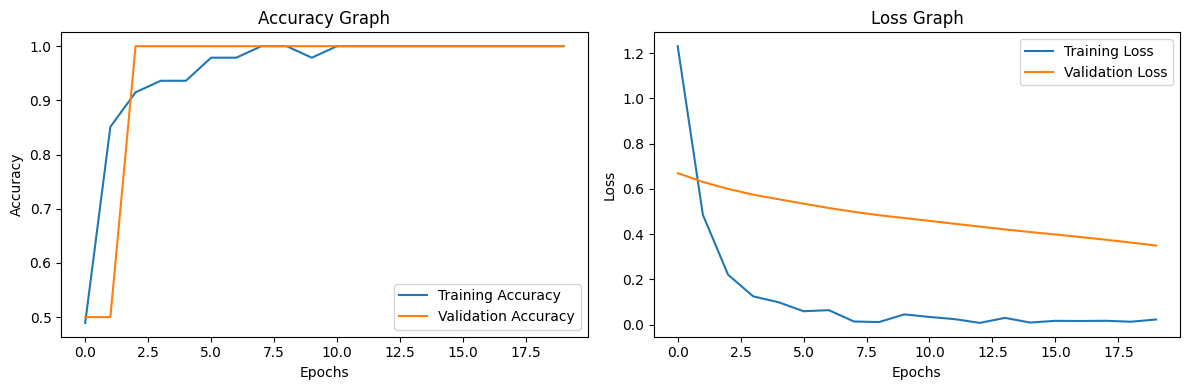

1/1 [==============================] - 2s 2s/step - loss: 0.3542 - accuracy: 1.0000
Test Accuracy: 100.00%
1/1 [==============================] - 3s 3s/step

Classification Report:
              precision    recall  f1-score   support

        hari       1.00      1.00      1.00        10
      ganesh       1.00      1.00      1.00         5

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



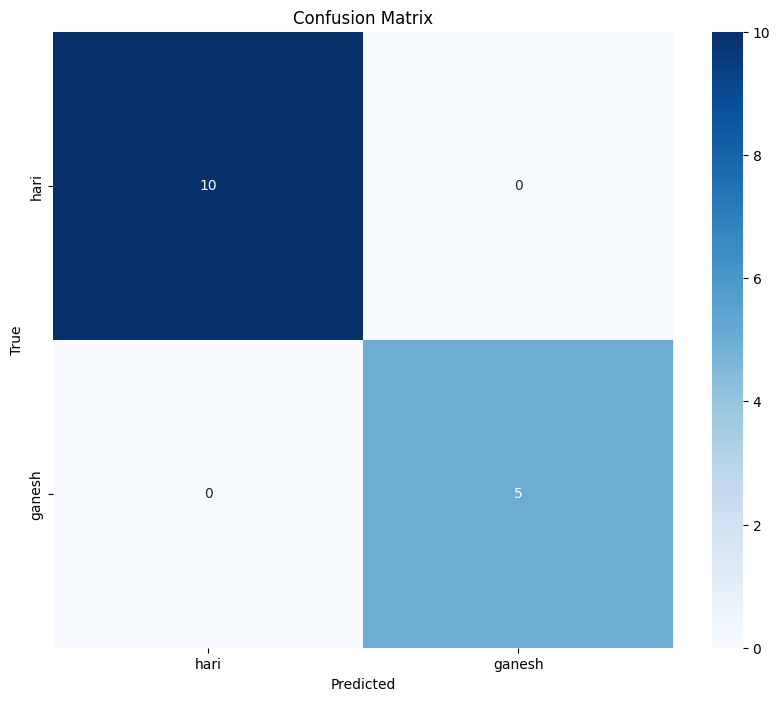

In [1]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)
y_train = to_categorical(y_train, num_classes=len(label_map))
y_test = to_categorical(y_test, num_classes=len(label_map))

# Hybrid VGG19 + Custom CNN model
def build_hybrid_model(num_classes):
    # Load VGG19 as feature extractor
    vgg_base = VGG19(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    for layer in vgg_base.layers:
        layer.trainable = False  # Freeze VGG19 layers

    # Add custom CNN layers after VGG19
    x = vgg_base.output
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Flatten the features and add fully connected layers
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    # Create the model
    model = Model(inputs=vgg_base.input, outputs=output)
    return model

# Build and compile the model
num_classes = len(label_map)
model = build_hybrid_model(num_classes)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks for training
checkpoint = ModelCheckpoint("hybrid_vgg19_cnn_model.h5", save_best_only=True, monitor='val_loss', mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=16,
    callbacks=[checkpoint, early_stopping]
)

# Plot accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Confusion matrix and classification report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_map.keys()))

conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [4]:
from tensorflow.keras.models import Model, load_model
import cv2
# Load the saved model
saved_model = load_model("vgg19_fingerprint_model.h5")
# Load Model and Predict with OpenCV
def predict_user(image_path, model, label_map):
    # Preprocess the input image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = np.stack((image,)*3, axis=-1)  # Convert to 3 channels
    image = image / 255.0  # Normalize
    image = np.expand_dims(image, axis=0)  # Add batch dimension

    # Predict the class
    prediction = model.predict(image)
    predicted_label = np.argmax(prediction)
    
    # Map the numeric label back to the user name
    user_name = {v: k for k, v in label_map.items()}[predicted_label]
    return user_name
# Capture an image using OpenCV
cap = cv2.VideoCapture(0)
print("Press 's' to capture an image or 'q' to quit.")

while True:
    ret, frame = cap.read()
    cv2.imshow('Capture Fingerprint', frame)
    key = cv2.waitKey(1)

    if key == ord('s'):  # Save image when 's' is pressed
        cv2.imwrite("captured_fingerprint.jpg", frame)
        cap.release()
        cv2.destroyAllWindows()
        predicted_user = predict_user("captured_fingerprint.jpg", saved_model, label_map)
        print(f"Predicted User: {predicted_user}")
        break

    elif key == ord('q'):  # Quit when 'q' is pressed
        cap.release()
        cv2.destroyAllWindows()
        break

Press 's' to capture an image or 'q' to quit.
1/1 [==============================] - 0s 359ms/step
Predicted User: ganesh
